# **Import de librairies**

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from tqdm import tqdm
import numpy as np
import re

# **Chargement du dataset**

In [3]:
df = pd.read_csv("SpotifyFeatures.csv")

# **EDA (Exploratory Data Analysis) + Nettoyage**

### **Exploration préliminaire**

In [4]:
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [6]:
print(f"Le dataset a désormais {len(df)} lignes.")

Le dataset a désormais 232725 lignes.


### **Traitement des valeurs nulles**

In [7]:
df.isna().sum()

genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

Une seule valeur nulle dans la colonne 'track_name'.

In [8]:
df[df['track_name'].isna()].index

Index([208285], dtype='int64')

In [9]:
df.iloc[208285]

genre                                World
artist_name              Elevation Worship
track_name                             NaN
track_id            7BGQCe62A58Q5ZgpQFX93t
popularity                              44
acousticness                         0.019
danceability                         0.287
duration_ms                         350027
energy                               0.446
instrumentalness                       0.0
key                                      F
liveness                               0.1
loudness                            -7.214
mode                                 Major
speechiness                         0.0317
tempo                              138.727
time_signature                         4/4
valence                             0.0387
Name: 208285, dtype: object

track_id = l'URI nous mène vers la track sur spotify
https://open.spotify.com/intl-fr/track/ 7BGQCe62A58Q5ZgpQFX93t 

Le titre du morceau s'appelle "None".

In [10]:
df = df.fillna('None')

### **Analyse et nettoyage des colonnes**

In [11]:
df.columns

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='object')

#### **Colonnes catégorielles**

In [12]:
colonnes_cat = df.select_dtypes(include=['object'])
colonnes_cat

,genre,artist_name,track_name,track_id,key,mode,time_signature
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,C#,Major,4/4
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,F#,Minor,4/4
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,C,Minor,5/4
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,C#,Major,4/4
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,F,Major,4/4
...,...,...,...,...,...,...,...
232720,Soul,Slave,Son Of Slide,2XGLdVl7lGeq8ksM6Al7jT,D,Major,4/4
232721,Soul,Jr Thomas & The Volcanos,Burning Fire,1qWZdkBl4UVPj9lK6HuuFM,E,Minor,4/4
232722,Soul,Muddy Waters,(I'm Your) Hoochie Coochie Man,2ziWXUmQLrXTiYjCg2fZ2t,D,Major,4/4
232723,Soul,R.LUM.R,With My Words,6EFsue2YbIG4Qkq8Zr9Rir,A,Major,4/4


##### ***Genre***

In [13]:
df['genre'].unique()

array(['Movie', 'R&B', 'A Capella', 'Alternative', 'Country', 'Dance',
       'Electronic', 'Anime', 'Folk', 'Blues', 'Opera', 'Hip-Hop',
       "Children's Music", 'Children’s Music', 'Rap', 'Indie',
       'Classical', 'Pop', 'Reggae', 'Reggaeton', 'Jazz', 'Rock', 'Ska',
       'Comedy', 'Soul', 'Soundtrack', 'World'], dtype=object)

erreur observée : "Children's Music", 'Children’s Music'

In [14]:
print(f"Il y a {df['genre'].nunique()} genres uniques dans le dataset" )

Il y a 27 genres uniques dans le dataset


In [15]:
df['genre'] = df['genre'].str.replace('’', "'", regex=False)
df['genre'] = df['genre'].str.lower().str.strip()

In [16]:
print(f"Il y a {df['genre'].nunique()} genres uniques dans le dataset" )

Il y a 26 genres uniques dans le dataset


In [17]:
df= df.drop(columns=['genre'])

In [18]:
print(f"Le dataset a désormais {len(df)} lignes.")

Le dataset a désormais 232725 lignes.


constat d'incohérence probant :imprim écran Céline Dion ou Francis Lalane 

Enrichissement à prévoir sur la colonne genre pour avoir plus de cohérence et retrouver la variété française.

##### ***Artist name***


In [19]:
print(f"Il y a {df['artist_name'].nunique()} noms d'artistes uniques dans ce dataset.")

Il y a 14564 noms d'artistes uniques dans ce dataset.


In [20]:
df['artist_name'].value_counts().head(28)

artist_name
Giuseppe Verdi              1394
Giacomo Puccini             1137
Kimbo Children's Music       971
Nobuo Uematsu                825
Richard Wagner               804
Wolfgang Amadeus Mozart      800
Randy Newman                 757
Georges Bizet                701
Juice Music                  684
Johann Sebastian Bach        632
Ludwig van Beethoven         596
Hans Zimmer                  559
Gioachino Rossini            491
Chorus                       480
Howard Shore                 479
Drake                        477
Henri Salvador               474
John Williams                450
Frédéric Chopin              436
Alan Menken                  420
Chris Brown                  392
Bob Marley & The Wailers     380
Dorothée                     378
Gaetano Donizetti            377
Children Songs Company       371
Max Richter                  365
Capcom Sound Team            326
Future                       317
Name: count, dtype: int64

In [21]:
df['artist_name'] = df['artist_name'].str.replace('’', "'",  regex=False)  # apostrophe typographique
df['artist_name'] = df['artist_name'].str.lower().str.strip()  # minuscule + suppression espaces    

In [22]:
print(f"Il y a {df['artist_name'].nunique()} noms d'artistes uniques dans ce dataset.")

Il y a 14561 noms d'artistes uniques dans ce dataset.


In [23]:
df.head(28)

,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,henri salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.61100,0.389,99373,0.9100,0.000000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.8140
1,martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.24600,0.590,137373,0.7370,0.000000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.8160
2,joseph williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.95200,0.663,170267,0.1310,0.000000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.3680
3,henri salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.70300,0.240,152427,0.3260,0.000000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.2270
4,fabien nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.95000,0.331,82625,0.2250,0.123000,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.3900
5,henri salvador,Le petit souper aux chandelles,0Mf1jKa8eNAf1a4PwTbizj,0,0.74900,0.578,160627,0.0948,0.000000,C#,0.1070,-14.970,Major,0.1430,87.479,4/4,0.3580
6,martin & les fées,"Premières recherches (par Paul Ventimila, Lori...",0NUiKYRd6jt1LKMYGkUdnZ,2,0.34400,0.703,212293,0.2700,0.000000,C#,0.1050,-12.675,Major,0.9530,82.873,4/4,0.5330
7,laura mayne,Let Me Let Go,0PbIF9YVD505GutwotpB5C,15,0.93900,0.416,240067,0.2690,0.000000,F#,0.1130,-8.949,Major,0.0286,96.827,4/4,0.2740
8,chorus,Helka,0ST6uPfvaPpJLtQwhE6KfC,0,0.00104,0.734,226200,0.4810,0.000860,C,0.0765,-7.725,Major,0.0460,125.080,4/4,0.7650
9,le club des juniors,Les bisous des bisounours,0VSqZ3KStsjcfERGdcWpFO,10,0.31900,0.598,152694,0.7050,0.001250,G,0.3490,-7.790,Major,0.0281,137.496,4/4,0.7180


Voir si pas d'autres fautes orthographes : 
- & et and par exemple.
- retirer The

L'artiste au plus grand nombre de titres dans le dataset est Verdi qui en compte 1394.

##### ***Track name***

In [24]:
print(f"Il y a {df['track_name'].nunique()} noms de titres uniques dans ce dataset.")

Il y a 148615 noms de titres uniques dans ce dataset.


In [25]:
df['track_name'] = df['track_name'].str.replace('’', "'",  regex=False)  # apostrophe typographique
df['track_name'] = df['track_name'].str.lower().str.strip()  # minuscule + suppression espaces    

In [26]:
print(f"Il y a {df['track_name'].nunique()} noms de titres uniques dans ce dataset.")

Il y a 145281 noms de titres uniques dans ce dataset.


Voir d'autres fautes d'orthographes.

#####  ***Track id***

In [27]:
df[df['track_id']=="0NOh9M0tIGappRjE5oVaUc"]

,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
9350,disturbed,legion of monsters,0NOh9M0tIGappRjE5oVaUc,50,0.000244,0.604,263640,0.988,0.000043,F,0.291,-2.361,Minor,0.0695,128.04,4/4,0.683
99501,disturbed,legion of monsters - bonus track,0NOh9M0tIGappRjE5oVaUc,55,0.000244,0.604,263640,0.988,0.000043,F,0.291,-2.361,Minor,0.0695,128.04,4/4,0.683


In [28]:
print(f"Le dataset a {len(df)} lignes.")

Le dataset a 232725 lignes.


In [29]:
print(f"Il y a {df['track_id'].nunique()} URI uniques dans ce dataset.")

Il y a 176774 URI uniques dans ce dataset.


In [30]:
print(f"Il y a {len(df)-(df['track_id'].nunique())} doublons dans le dataset")

Il y a 55951 doublons dans le dataset


In [31]:
df['track_id'].value_counts().head(28)

track_id
6sVQNUvcVFTXvlk3ec0ngd    8
3R73Y7X53MIQZWnKloWq5i    8
6AIte2Iej1QKlaofpjCzW1    8
0UE0RhnRaEYsiYgXpyLoZc    8
3uSSjnDMmoyERaAK9KvpJR    8
0wY9rA9fJkuESyYm9uzVK5    8
5g3TDpgy1J1woAUVuj21EE    7
3nXrCAE44KlevAkQB2XWcN    7
6M6UoxIPn4NOWW0x7JPRfv    7
6NqbN00vLmWfrQSx2wjD4z    7
3GZD6HmiNUhxXYf8Gch723    7
4tggZyGJMNJMooWuRbvN5q    7
5rAff9XfcWx7rguN3t0fkW    7
1FTSo4v6BOZH9QxKc3MbVM    7
5gW5dSy3vXJxgzma4rQuzH    7
2q0VexHJirnUPnEOhr2DxK    7
5lcyIeEfwZTs8Ajw3kdF7P    7
7qCZgvV98j6RjUULW1s1it    7
6TFUZ8Bt1brEwomY90SKXi    7
4bnjq8zqtCnxTGxll5ezOO    7
5YxaccATvDTIOpue7vu6Tn    7
7rAUH8YZRvGyZ5wmoKjYbG    7
2CInzVilMduj9L8dDXwyUA    7
6INaSJ4clfZ8pvXSGZQnJ7    7
6NueIkCzLhp4rXpNAiXDdh    7
1HwbgJAU9PZ7YbzKgVgoIF    7
2gE0khQ948RYQOeTgCUL2a    7
0725YWm6Z0TpZ6wrNk64Eb    7
Name: count, dtype: int64

In [32]:
df[df['track_id']== '6sVQNUvcVFTXvlk3ec0ngd']

,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
10230,cocteau twins,cherry-coloured funk,6sVQNUvcVFTXvlk3ec0ngd,57,0.00174,0.377,192467,0.65,0.000058,D,0.107,-5.902,Major,0.029,180.074,4/4,0.365
20391,cocteau twins,cherry-coloured funk,6sVQNUvcVFTXvlk3ec0ngd,61,0.00174,0.377,192467,0.65,0.000058,D,0.107,-5.902,Major,0.029,180.074,4/4,0.365
22947,cocteau twins,cherry-coloured funk,6sVQNUvcVFTXvlk3ec0ngd,61,0.00174,0.377,192467,0.65,0.000058,D,0.107,-5.902,Major,0.029,180.074,4/4,0.365
44871,cocteau twins,cherry-coloured funk,6sVQNUvcVFTXvlk3ec0ngd,61,0.00174,0.377,192467,0.65,0.000058,D,0.107,-5.902,Major,0.029,180.074,4/4,0.365
102041,cocteau twins,cherry-coloured funk,6sVQNUvcVFTXvlk3ec0ngd,61,0.00174,0.377,192467,0.65,0.000058,D,0.107,-5.902,Major,0.029,180.074,4/4,0.365
141335,cocteau twins,cherry-coloured funk,6sVQNUvcVFTXvlk3ec0ngd,61,0.00174,0.377,192467,0.65,0.000058,D,0.107,-5.902,Major,0.029,180.074,4/4,0.365
153467,cocteau twins,cherry-coloured funk,6sVQNUvcVFTXvlk3ec0ngd,61,0.00174,0.377,192467,0.65,0.000058,D,0.107,-5.902,Major,0.029,180.074,4/4,0.365
207908,cocteau twins,cherry-coloured funk,6sVQNUvcVFTXvlk3ec0ngd,61,0.00174,0.377,192467,0.65,0.000058,D,0.107,-5.902,Major,0.029,180.074,4/4,0.365


In [33]:
df.groupby(['artist_name', 'track_name']).size().reset_index(name='count').query('count > 1')

,artist_name,track_name,count
6,!!!,even when the water's cold,6
16,!!!,lucy mongoosey,2
36,"""weird al"" yankovic","amish paradise (parody of ""gangsta's paradise""...",2
102,$uicideboy$,$outh $ide $uicide,2
103,$uicideboy$,"10,000 degrees",2
...,...,...,...
175329,ñejo,se te hizo tarde,2
175362,ñejo & dalmata,pasarela,2
175369,ñejo & dalmata,sexo en la playa,2
175382,ólafur arnalds,dalur - island songs v,2


In [34]:
# Identifier les track_id qui apparaissent plus d'une fois
df_duplicates = df[df.duplicated(subset=['track_id'])]
df_duplicates

,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
1348,doja cat,go to town,6iOvnACn4ChlAw4lWUU4dd,64,0.07160,0.710,217813,0.710,0.000001,C,0.2060,-2.474,Major,0.0579,169.944,4/4,0.700
1385,frank ocean,seigfried,1BViPjTT585XAhkUUrkts0,61,0.97500,0.377,334570,0.255,0.000208,E,0.1020,-11.165,Minor,0.0387,125.004,5/4,0.370
1452,frank ocean,bad religion,2pMPWE7PJH1PizfgGRMnR9,56,0.77900,0.276,175453,0.358,0.000003,A,0.0728,-7.684,Major,0.0443,81.977,4/4,0.130
1554,steve lacy,some,4riDfclV7kPDT9D58FpmHd,58,0.00548,0.784,118393,0.554,0.254000,G,0.0995,-6.417,Major,0.0300,104.010,4/4,0.634
1634,tobi lou,buff baby,1F1QmI8TMHir9SUFrooq5F,59,0.19000,0.736,215385,0.643,0.000000,F,0.1060,-8.636,Major,0.0461,156.002,4/4,0.599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232715,emily king,down,5cA0vB8c9FMOVDWyJHgf26,42,0.55000,0.394,281853,0.346,0.000002,E,0.1290,-13.617,Major,0.0635,90.831,4/4,0.436
232718,muddy waters,i just want to make love to you - electric mud...,2HFczeynfKGiM9KF2z2K7K,43,0.01360,0.294,258267,0.739,0.004820,C,0.1380,-7.167,Major,0.0434,176.402,4/4,0.945
232720,slave,son of slide,2XGLdVl7lGeq8ksM6Al7jT,39,0.00384,0.687,326240,0.714,0.544000,D,0.0845,-10.626,Major,0.0316,115.542,4/4,0.962
232722,muddy waters,(i'm your) hoochie coochie man,2ziWXUmQLrXTiYjCg2fZ2t,47,0.90100,0.517,166960,0.419,0.000000,D,0.0945,-8.282,Major,0.1480,84.135,4/4,0.813


In [35]:
audio_features = ['acousticness', 'danceability', 'duration_ms', 'energy', 
                  'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 
                  'speechiness', 'tempo', 'time_signature', 'valence']

# Identifier les track_id avec des valeurs incohérentes
problematic_tracks = []

for track_id, group in df_duplicates.groupby('track_id'):
    for col in audio_features:
        if group[col].nunique() > 1:
            problematic_tracks.append(track_id)
            break  

print(f"Nombre de track_id incohérents : {len(problematic_tracks)}")
print("Liste des track_id :")
print(problematic_tracks)

Nombre de track_id incohérents : 9
Liste des track_id :
['1o4aDH0BYwZdSEm7fJzYhD', '3Y1skP4N1zbrSuH1xfLm9k', '3hFIXFEPtvruqYsoMW2eKN', '3tUdpqlrhZONJBRVXDxegM', '4I5uWfaZIrkKCHrbO7eLMV', '4PIrQHxXlHlSXKoKd2nuxE', '6GQoR1abZRKj3R41nJqTX6', '6UNV8mflEmh8PJqeTPC1p3', '7N0T6i3ZER3p3SYBzxMeCV']


In [36]:
# Supprimer ces track_id du DataFrame
df_clean = df[~df['track_id'].isin(problematic_tracks)]

print(f"Lignes supprimées : {len(df) - len(df_clean)}")
print(f"DataFrame nettoyé : {len(df_clean)} lignes")

Lignes supprimées : 32
DataFrame nettoyé : 232693 lignes


In [37]:
# Garder la ligne avec la popularité max pour chaque track_id
df = df_clean.loc[df_clean.groupby('track_id')['popularity'].idxmax()]
df

,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
34788,capcom sound team,zangief's theme,00021Wy6AyMbLP2tqij86e,13,0.2340,0.617,169173,0.862,0.976000,G,0.1410,-12.855,Major,0.0514,129.578,4/4,0.886
546,henri salvador,coeur brisé à prendre - remastered,000CzNKC8PEt1yC3L8dqwV,5,0.2490,0.518,130653,0.805,0.000000,F,0.3330,-6.248,Major,0.0407,79.124,4/4,0.841
136665,mike love,earthlings,000DfZJww8KiixTKuk9usJ,30,0.3660,0.631,357573,0.513,0.000004,D,0.1090,-6.376,Major,0.0293,120.365,4/4,0.307
177169,don philippe,fewerdolr,000EWWBkYaREzsBplYjUag,39,0.8150,0.768,104924,0.137,0.922000,C#,0.1130,-13.284,Minor,0.0747,76.430,4/4,0.560
14492,zayn,still got time,000xQL6tZNLJzIrtIgxqSl,70,0.1310,0.748,188491,0.627,0.000000,G,0.0852,-6.029,Major,0.0644,120.963,4/4,0.524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147669,caravan palace,maniac,7zz7MbCb9G7KJc1NVl9bL0,38,0.4000,0.851,251267,0.790,0.230000,C,0.1230,-4.641,Minor,0.0309,111.993,4/4,0.889
176037,thelonious monk quartet,crepescule with nellie - live at carnegie hall...,7zzFNNxVD0h0ctAT08H0pa,40,0.9730,0.538,266933,0.144,0.177000,G#,0.3590,-17.711,Major,0.0569,135.640,3/4,0.110
163359,magnate y valentino,una en un millón,7zzTeItz93lYI52hlcipm5,28,0.1130,0.716,228493,0.806,0.000000,G,0.1510,-5.913,Minor,0.1350,136.069,4/4,0.544
100080,moonstar88,migraine,7zzZmpw8L66ZPjH1M6qmOs,67,0.2170,0.664,267960,0.537,0.000003,D,0.1180,-6.000,Major,0.0290,115.049,4/4,0.221


##### **Analyse croisée artist_name / track_name :**

In [38]:
df[df['artist_name'] == 'giuseppe verdi']['track_name'].value_counts().head(28)

track_name
la traviata / act 2: "dammi tu forza, o cielo!"                      2
la traviata / act 2: "noi siamo zingarelle"                          2
la traviata / act 3: "prendi, quest'è l'immagine"                    2
la traviata / act 2: "alfredo! voi!"                                 2
la traviata / act 2: "di sprezzo degno se stesso rende"              2
la traviata / act 2: "avrem lieta di maschere la notte"              2
la traviata / act 1: "dell'invito trascorsa è già l'ora"             2
la traviata / act 2: "lunge da lei" - "de' miei bollenti spiriti"    2
la forza del destino: overture                                       2
la traviata / act 1: "e strano!" - "ah, fors'è lui"                  2
la traviata / act 2: "alfredo, alfredo, di questo core"              2
la traviata / act 2: "ah, vive sol quel core"                        2
la traviata / act 2: "ah! dite alla giovine"                         2
la traviata / act 1: prelude                                      

En prenant Verdi pour exemple on observe qu'un même titre peut apparaitre plusieurs fois dans le dataset.

Pour éviter les doublons, nous conservons la version la plus populaire pour chaque couple track_name / artist_name.

In [39]:
df= df.loc[df.groupby(['track_name', 'artist_name'])['popularity'].idxmax()]
print(f"Le dataset a désormais {len(df)} lignes.")

Le dataset a désormais 175489 lignes.


In [40]:
df[df['artist_name'] == 'giuseppe verdi']['track_name'].value_counts().head()

track_name
レクイエム 3. offertorio (all-4)                                        1
"ah, violetta!" "voi? signor?"                                     1
"alta cagion v'aduna"                                              1
"che veggo!...egli?...mio padre!"                                  1
verdi: nabucco, act 3: "va, pensiero, sull'ali dorate" (chorus)    1
Name: count, dtype: int64

##### ***Key***

In [41]:
df['key'].unique()

array(['F', 'C#', 'G#', 'C', 'D', 'D#', 'G', 'B', 'A#', 'A', 'E', 'F#'],
      dtype=object)

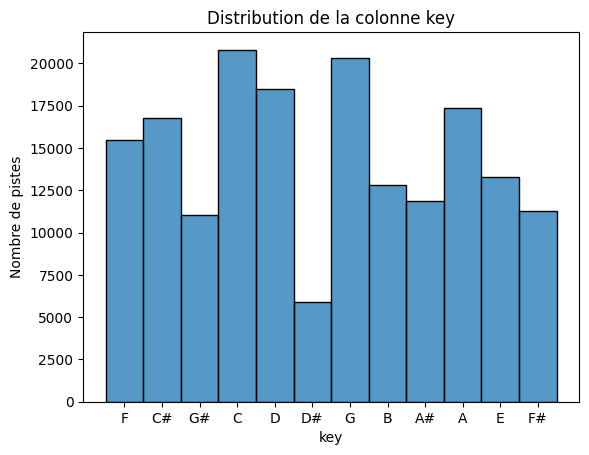

In [42]:
counts_key = df['key'].value_counts()
sns.histplot(data=df, x="key")
plt.title('Distribution de la colonne key')
plt.xlabel('key')
plt.ylabel('Nombre de pistes')
plt.show()

/tmp/ipykernel_10463/2659825684.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


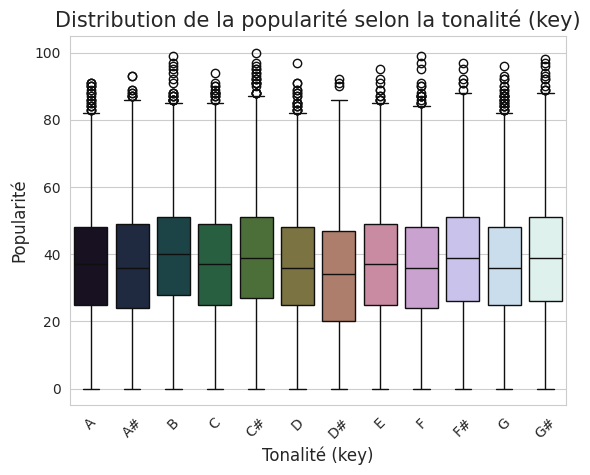

In [43]:
# Boxplot pour la variable "key"
# Objectif : visualiser la distribution d'une variable numérique (par exemple "popularity") selon chaque tonalité ("key")

sns.set_style("whitegrid")  # Ajoute une grille de fond pour une meilleure lisibilité

# Création du boxplot : on affiche la distribution de la popularité pour chaque "key"
ax = sns.boxplot(
    data=df,                  # DataFrame contenant les données
    x="key",                          # Variable catégorielle sur l'axe des x (tonalité)
    y="popularity",                   # Variable numérique sur l'axe des y (exemple : popularité)
    palette="cubehelix",              # Palette de couleurs pour différencier les tonalités
    order=sorted(df["key"].unique())  # Trie les tonalités pour un affichage ordonné
)

# Ajout d'un titre et de labels explicites pour les axes
plt.title('Distribution de la popularité selon la tonalité (key)', fontsize=15)
plt.xlabel('Tonalité (key)', fontsize=12)
plt.ylabel('Popularité', fontsize=12)

# Optionnel : rotation des labels x pour une meilleure lisibilité
plt.xticks(rotation=45)

# Affichage du graphique final
plt.show()

Voir les corrélations avec mode et valence dans la suite de l'analyse.

Commentaire d'analyse

##### ***Mode***

In [44]:
df["mode"].unique()

array(['Major', 'Minor'], dtype=object)

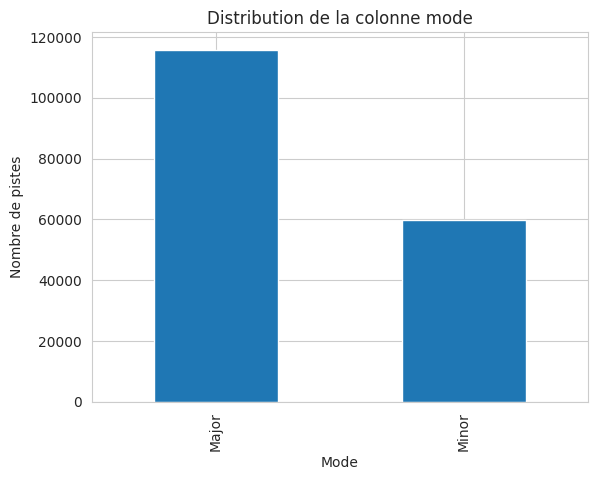

In [45]:
counts = df['mode'].value_counts()
counts.plot(kind='bar')
plt.title('Distribution de la colonne mode')
plt.xlabel('Mode')
plt.ylabel('Nombre de pistes')
plt.show()

COmmentaires?

##### ***Time signature***

In [46]:
df['time_signature'].describe()

count     175489
unique         5
top          4/4
freq      148114
Name: time_signature, dtype: object

In [47]:
df['time_signature'].unique()

array(['4/4', '3/4', '5/4', '1/4', '0/4'], dtype=object)

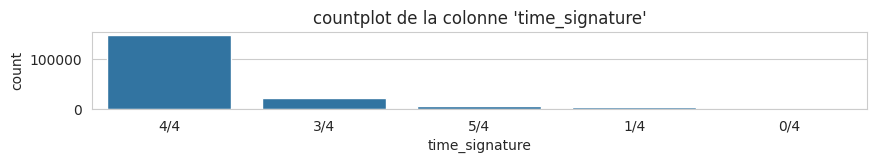

In [48]:
plt.figure(figsize=(10, 1))
sns.countplot(x=df['time_signature'])
plt.title("countplot de la colonne 'time_signature'")
plt.show()

- je supprime les valeurs aberrantes 0 Impossible en musique → à supprimer
- et 1 Musicalement peu plausible → probablement une erreur de parsing ou un tag incohérent

Verifier 1/4 si la valeur n'est pas mal enregistrée.

In [49]:
# Extraire uniquement le numérateur de la signature (4, 5, 3, etc.) pour en faire une colonne numérique propre.
# Étape 1 : Extraire la partie avant le '/' et la convertir en entier
df['time_signature_clean'] = df['time_signature'].str.extract(r'^(\d+)').astype('Int64')
df['time_signature'] = df['time_signature_clean']
df.drop(columns='time_signature_clean', inplace=True)


df = df[df['time_signature'].isin([1, 3, 4, 5])]
df

,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
58300,maria callas,""" la traviata "" : amami alfredo (act ii) - dig...",0wtpkz93wATDkUExJVuXEl,31,0.993000,0.364,131933,0.275,0.028400,F,0.293,-11.832,Major,0.0430,86.096,4,0.0394
32571,yuki hayashi,"""1点""",7JkDONXIbcKUQ7QzlLBumL,23,0.025000,0.250,158000,0.762,0.516000,C#,0.094,-12.794,Minor,0.0468,89.093,3,0.0835
89661,rae sremmurd,"""42"" - from sr3mm",5lf91lPnGKtIqsgmG1z8Ip,53,0.002750,0.968,238020,0.563,0.000000,C#,0.108,-6.744,Major,0.1250,130.039,4,0.3240
142359,the gaslight anthem,"""45""",25Sd73fleKUVPNqITPZkn1,48,0.000696,0.315,202493,0.970,0.000000,G#,0.277,-4.709,Major,0.1020,178.068,4,0.4230
33675,yuki hayashi,"""6人で(強い方が強い)""",0qwK0LvMyAQ7J1rEEL6nbr,17,0.971000,0.176,171000,0.125,0.904000,C,0.129,-16.699,Major,0.0349,136.076,3,0.0461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150871,got7,하드캐리 hard carry,7Cd4glTUgV0vr0DBncEg8S,63,0.014800,0.700,193579,0.873,0.000000,C#,0.343,-2.901,Major,0.0869,99.972,4,0.6120
219320,park hyo shin,해줄 수 없는 일 haejul su eomneun il,3Kk075LR7Bj2bUH1mB3TIZ,30,0.729000,0.332,260600,0.493,0.000000,C,0.165,-6.126,Major,0.0318,110.024,4,0.1550
149889,day6,행복했던 날들이었다 days gone by,3TE3SbiWrm69WyUl8BlZEV,64,0.002110,0.613,205149,0.874,0.000000,C,0.134,-3.712,Minor,0.0335,102.975,4,0.6510
220337,lee moon sae,휘파람,3G9dGrDJAPTDtJCGk8VF5i,27,0.513000,0.521,298760,0.423,0.000004,D,0.131,-6.770,Minor,0.0324,59.036,4,0.2740


#### **Colonnes numériques**

In [50]:
# Sélection numérique
colonnes_num = df.select_dtypes(include=['float64', 'int64'])
colonnes_num

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature,valence
58300,31,0.993000,0.364,131933,0.275,0.028400,0.293,-11.832,0.0430,86.096,4,0.0394
32571,23,0.025000,0.250,158000,0.762,0.516000,0.094,-12.794,0.0468,89.093,3,0.0835
89661,53,0.002750,0.968,238020,0.563,0.000000,0.108,-6.744,0.1250,130.039,4,0.3240
142359,48,0.000696,0.315,202493,0.970,0.000000,0.277,-4.709,0.1020,178.068,4,0.4230
33675,17,0.971000,0.176,171000,0.125,0.904000,0.129,-16.699,0.0349,136.076,3,0.0461
...,...,...,...,...,...,...,...,...,...,...,...,...
150871,63,0.014800,0.700,193579,0.873,0.000000,0.343,-2.901,0.0869,99.972,4,0.6120
219320,30,0.729000,0.332,260600,0.493,0.000000,0.165,-6.126,0.0318,110.024,4,0.1550
149889,64,0.002110,0.613,205149,0.874,0.000000,0.134,-3.712,0.0335,102.975,4,0.6510
220337,27,0.513000,0.521,298760,0.423,0.000004,0.131,-6.770,0.0324,59.036,4,0.2740


In [51]:
df.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature,valence
count,175483.000000,175483.000000,175483.000000,1.754830e+05,175483.000000,175483.000000,175483.000000,175483.000000,175483.000000,175483.000000,175483.0,175483.000000
mean,36.542776,0.403692,0.541158,2.361228e+05,0.557356,0.172521,0.224696,-10.134557,0.127689,117.201557,3.867765,0.451438
std,17.572564,0.366243,0.190437,1.303381e+05,0.275754,0.323261,0.211232,6.398429,0.204812,31.315203,0.494534,0.267788
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,1.0,0.000000
25%,25.000000,0.045450,0.415000,1.782750e+05,0.344000,0.000000,0.097500,-12.845000,0.036800,92.006000,4.0,0.222000
50%,37.000000,0.287000,0.558000,2.194800e+05,0.593000,0.000071,0.130000,-8.186000,0.049500,115.009000,4.0,0.440000
75%,49.000000,0.790000,0.683000,2.686000e+05,0.789000,0.092700,0.277000,-5.627500,0.102000,138.799500,4.0,0.667000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,5.0,1.000000


##### ***Popularity***

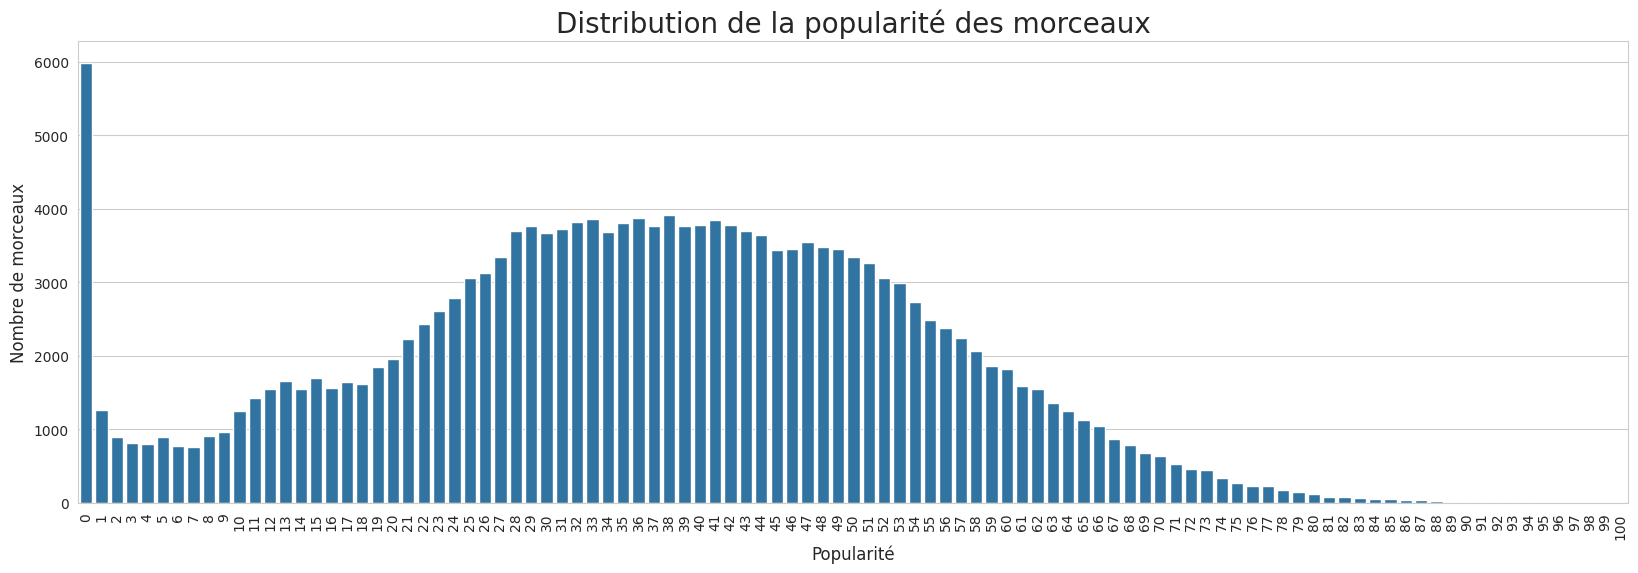

In [52]:
plt.figure(figsize=(20, 6))  
sns.countplot(data=df,
              x='popularity')

plt.title('Distribution de la popularité des morceaux', fontsize=20)
plt.xlabel('Popularité', fontsize=12)
plt.ylabel('Nombre de morceaux', fontsize=12)
plt.xticks(rotation=90)  
plt.show()

Pour chaque titre de chanson unique (track_name) sélectionne la ligne ayant la popularité maximale (popularity) dans le DataFrame df.

In [53]:
df = df.loc[df.groupby('track_name')['popularity'].idxmax()]

On décide de ne garder que les scores au dessus de 20/100 de popularité.

In [54]:
df = df[df['popularity'] >= 20] 

In [55]:
print(f"Le dataset a désormais {len(df)} lignes.")  

Le dataset a désormais 119622 lignes.


##### ***Acousticness***

In [ ]:
# Analyse approfondie de la variable acousticness par genre musical


# Sélection des 10 genres les plus fréquents
top_genres = df['genre'].value_counts().head(10).index
df_top_genres = df[df['genre'].isin(top_genres)]

# Visualisation par boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_top_genres, x='genre', y='acousticness', palette='Set2')
plt.title("Distribution de l'acousticness par genre musical (Top 10)")
plt.ylabel("Acousticness (0 = électronique, 1 = acoustique)")
plt.xlabel("Genre musical")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 💡 Interprétation intégrée
print("""
INTERPRÉTATION :
- Chaque genre présente une dispersion importante de acousticness.
- Cela reflète :
    1. La diversité interne du genre (ex : pop acoustique vs synthpop)
    2. Les mélanges de styles (ex : rap acoustique)
    3. Des erreurs ou approximations dans la classification du genre
    4. L’utilisation d’instruments simulés ou acoustiques en production électronique
- Les outliers ne sont pas nécessairement des erreurs, mais peuvent être révélateurs d’originalité artistique.
""")

INTERPRÉTATION :
- Chaque genre présente une dispersion importante de acousticness.
- Cela reflète :
    1. La diversité interne du genre (ex : pop acoustique vs synthpop)
    2. Les mélanges de styles (ex : rap acoustique)
    3. Des erreurs ou approximations dans la classification du genre
    4. L’utilisation d’instruments simulés ou acoustiques en production électronique
- Les outliers ne sont pas nécessairement des erreurs, mais peuvent être révélateurs d’originalité artistique.

##### ***Danceability***

In [ ]:
#  Analyse approfondie de la variable danceability par genre musical

# Sélection des 10 genres les plus fréquents
top_genres = df['genre'].value_counts().head(10).index
df_top_genres = df[df['genre'].isin(top_genres)]

# Visualisation par boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_top_genres, x='genre', y='danceability', palette='coolwarm')
plt.title("Distribution de la danceability par genre musical (Top 10)")
plt.ylabel("Danceability (0 = difficile à danser, 1 = très dansant)")
plt.xlabel("Genre musical")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 💡 Interprétation intégrée
print("""
INTERPRÉTATION :
- La danceability mesure la propension d’un morceau à faire danser (basée sur le tempo, la régularité, etc.).
- EDM, Reggaeton, Hip-Hop ou Pop ont des valeurs de danceability plus élevées.
- Le Jazz ou le Classique ont une danceability plus faible, mais parfois avec des exceptions (outliers).
- Cette dispersion reflète :
    1. La diversité rythmique au sein d’un genre.
    2. Des mélanges de styles (ex : jazz-funk, pop chill).
    3. Des pistes étiquetées par erreur ou de manière trop générique.
- Comme pour acousticness, les outliers peuvent être des titres hybrides ou innovants.
""")

INTERPRÉTATION :
- La danceability mesure la propension d’un morceau à faire danser (basée sur le tempo, la régularité, etc.).
- EDM, Reggaeton, Hip-Hop ou Pop ont des valeurs de danceability plus élevées.
- Le Jazz ou le Classique ont une danceability plus faible, mais parfois avec des exceptions (outliers).
- Cette dispersion reflète :
    1. La diversité rythmique au sein d’un genre.
    2. Des mélanges de styles (ex : jazz-funk, pop chill).
    3. Des pistes étiquetées par erreur ou de manière trop générique.
- Comme pour acousticness, les outliers peuvent être des titres hybrides ou innovants.

##### ***Duration ms***

In [56]:
# duration_ms entre 1min et 6min
df = df[(df['duration_ms'] >= 60000) & (df['duration_ms'] <= 360000)]

##### ***Energy***

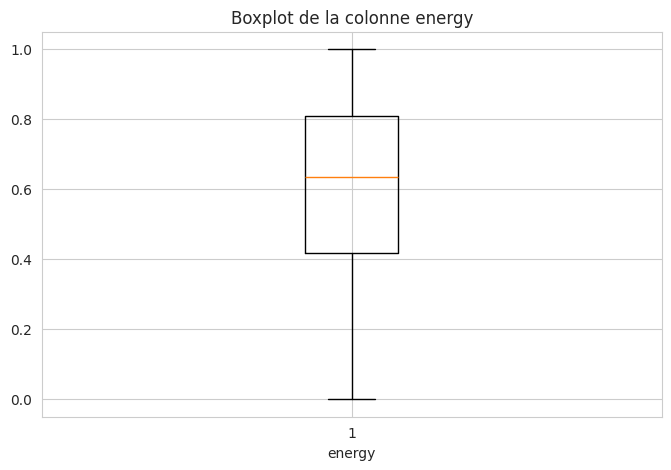

In [57]:
plt.figure(figsize=(8, 5))
plt.boxplot(x= df['energy'])

plt.title('Boxplot de la colonne energy')
plt.xlabel('energy')

plt.show()

- La médiane au-dessus de 0.6 montre que plus de la moitié des morceaux ont un niveau d’énergie modéré à élevé.
- Possible classification à réaliser morceaux en faible / moyenne / forte énergie pour répondre à l'activité

##### ***Instrumentalness***

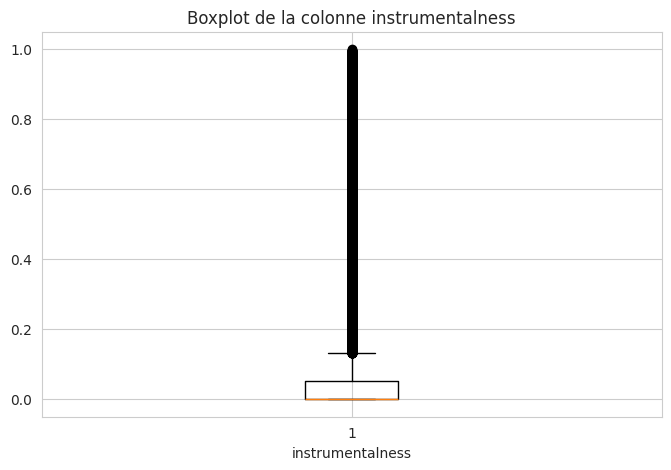

In [58]:
plt.figure(figsize=(8, 5))
plt.boxplot(x= df['instrumentalness'])

plt.title('Boxplot de la colonne instrumentalness')
plt.xlabel('instrumentalness')

plt.show()

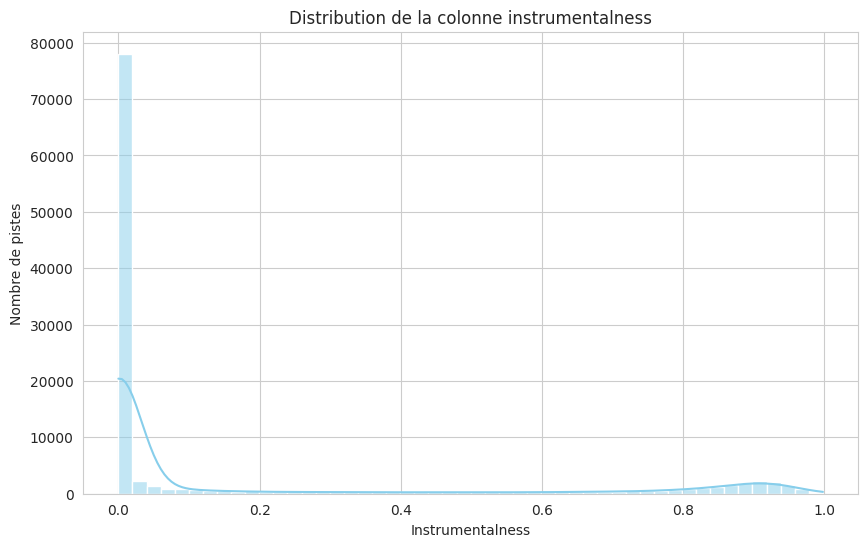

In [59]:
plt.figure(figsize=(10, 6))
sns.histplot(df['instrumentalness'], bins=50, kde=True, color='skyblue')

plt.title('Distribution de la colonne instrumentalness')
plt.xlabel('Instrumentalness')
plt.ylabel('Nombre de pistes')
plt.grid(True)
plt.show()


- La base de données est largement dominée par des chansons vocales.
- Pas de nettoyage à réaliser.

##### ***Liveness***

In [60]:
df['liveness'].describe()

count    108404.000000
mean          0.210235
std           0.192533
min           0.010500
25%           0.096800
50%           0.127000
75%           0.258000
max           1.000000
Name: liveness, dtype: float64

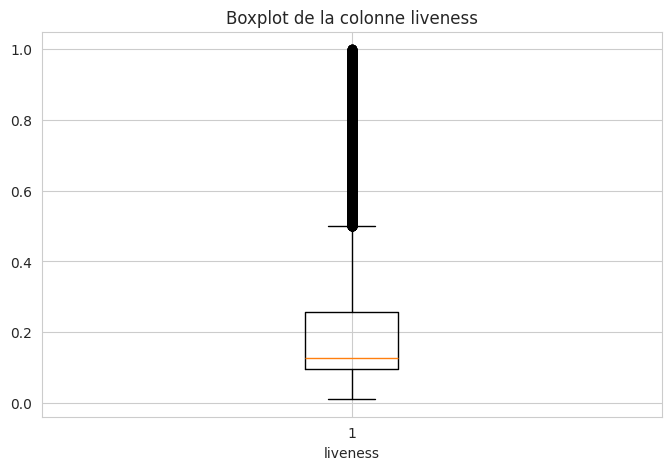

In [61]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['liveness'])

plt.title('Boxplot de la colonne liveness')
plt.xlabel('liveness')

plt.show()


- Le dataset est majoritairement composé de musique studio.
- Plus de 50 % des chansons n'ont que peu ou pas de caractéristiques live.
- Un seuil à 0.8 reste raisonnable pour retirer les vraies captations live.
- Un seuil à 0.5 "possiblement live"

In [62]:
df = df[df['liveness'] < 0.8]
df

,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
58300,maria callas,""" la traviata "" : amami alfredo (act ii) - dig...",0wtpkz93wATDkUExJVuXEl,31,0.993000,0.364,131933,0.275,0.028400,F,0.293,-11.832,Major,0.0430,86.096,4,0.0394
32571,yuki hayashi,"""1点""",7JkDONXIbcKUQ7QzlLBumL,23,0.025000,0.250,158000,0.762,0.516000,C#,0.094,-12.794,Minor,0.0468,89.093,3,0.0835
89661,rae sremmurd,"""42"" - from sr3mm",5lf91lPnGKtIqsgmG1z8Ip,53,0.002750,0.968,238020,0.563,0.000000,C#,0.108,-6.744,Major,0.1250,130.039,4,0.3240
142359,the gaslight anthem,"""45""",25Sd73fleKUVPNqITPZkn1,48,0.000696,0.315,202493,0.970,0.000000,G#,0.277,-4.709,Major,0.1020,178.068,4,0.4230
77209,barns courtney,"""99""",6YQUuoMnRIMaOmouYoMfQr,69,0.005980,0.552,199413,0.804,0.000000,G#,0.111,-4.299,Major,0.0303,95.980,4,0.7140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150871,got7,하드캐리 hard carry,7Cd4glTUgV0vr0DBncEg8S,63,0.014800,0.700,193579,0.873,0.000000,C#,0.343,-2.901,Major,0.0869,99.972,4,0.6120
219320,park hyo shin,해줄 수 없는 일 haejul su eomneun il,3Kk075LR7Bj2bUH1mB3TIZ,30,0.729000,0.332,260600,0.493,0.000000,C,0.165,-6.126,Major,0.0318,110.024,4,0.1550
149889,day6,행복했던 날들이었다 days gone by,3TE3SbiWrm69WyUl8BlZEV,64,0.002110,0.613,205149,0.874,0.000000,C,0.134,-3.712,Minor,0.0335,102.975,4,0.6510
220337,lee moon sae,휘파람,3G9dGrDJAPTDtJCGk8VF5i,27,0.513000,0.521,298760,0.423,0.000004,D,0.131,-6.770,Minor,0.0324,59.036,4,0.2740


In [63]:
# On observe la présence de live dans les titres
df_live = df[df['track_name'].str.contains(r'\blive\b', case=False, na=False, regex=True)]
# df_live.to_csv("live.csv", index=False)

On constate la récurrence de "- live", "(live)", "[live]".

On retire les lignes qui contiennent ces motifs.

In [64]:
df_without_live = df[~df['track_name'].str.contains(r'(?:-\s*live\b|\(live\)|\[live\])', case=False, na=False, regex=True)]
print(f"On retire {len(df) - len(df_without_live)} lignes.")

On retire 1697 lignes.


df_live.head()

In [65]:
df = df[~df['track_name'].str.contains(r"(?:-\s*live\b|\(live\)|\[live\])", case=False, na=False, regex=True)]

In [66]:
print(f"Le dataset a désormais {len(df)} lignes.")

Le dataset a désormais 103422 lignes.


##### ***Tempo***

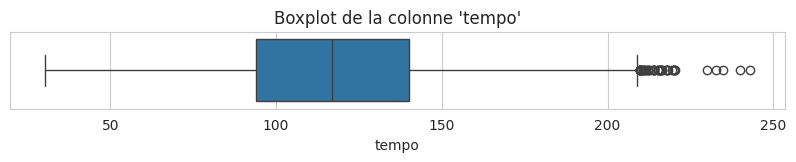

In [67]:
plt.figure(figsize=(10, 1))
sns.boxplot(x=df['tempo'])
plt.title("Boxplot de la colonne 'tempo'")
plt.show()

In [68]:
# Calcul des bornes IQR
Q1 = df['tempo'].quantile(0.25)
Q3 = df['tempo'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Borne basse : {lower_bound:.2f}")
print(f"Borne haute : {upper_bound:.2f}")

Borne basse : 24.70
Borne haute : 209.16


In [69]:
# on clean en gardant les valeurs entre les bornes
df = df[(df['tempo'] >= 23.82) & (df['tempo'] <= 208.20)]
df

,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
58300,maria callas,""" la traviata "" : amami alfredo (act ii) - dig...",0wtpkz93wATDkUExJVuXEl,31,0.993000,0.364,131933,0.275,0.028400,F,0.293,-11.832,Major,0.0430,86.096,4,0.0394
32571,yuki hayashi,"""1点""",7JkDONXIbcKUQ7QzlLBumL,23,0.025000,0.250,158000,0.762,0.516000,C#,0.094,-12.794,Minor,0.0468,89.093,3,0.0835
89661,rae sremmurd,"""42"" - from sr3mm",5lf91lPnGKtIqsgmG1z8Ip,53,0.002750,0.968,238020,0.563,0.000000,C#,0.108,-6.744,Major,0.1250,130.039,4,0.3240
142359,the gaslight anthem,"""45""",25Sd73fleKUVPNqITPZkn1,48,0.000696,0.315,202493,0.970,0.000000,G#,0.277,-4.709,Major,0.1020,178.068,4,0.4230
77209,barns courtney,"""99""",6YQUuoMnRIMaOmouYoMfQr,69,0.005980,0.552,199413,0.804,0.000000,G#,0.111,-4.299,Major,0.0303,95.980,4,0.7140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150871,got7,하드캐리 hard carry,7Cd4glTUgV0vr0DBncEg8S,63,0.014800,0.700,193579,0.873,0.000000,C#,0.343,-2.901,Major,0.0869,99.972,4,0.6120
219320,park hyo shin,해줄 수 없는 일 haejul su eomneun il,3Kk075LR7Bj2bUH1mB3TIZ,30,0.729000,0.332,260600,0.493,0.000000,C,0.165,-6.126,Major,0.0318,110.024,4,0.1550
149889,day6,행복했던 날들이었다 days gone by,3TE3SbiWrm69WyUl8BlZEV,64,0.002110,0.613,205149,0.874,0.000000,C,0.134,-3.712,Minor,0.0335,102.975,4,0.6510
220337,lee moon sae,휘파람,3G9dGrDJAPTDtJCGk8VF5i,27,0.513000,0.521,298760,0.423,0.000004,D,0.131,-6.770,Minor,0.0324,59.036,4,0.2740


In [70]:
print(f"Le dataset a désormais {len(df)} lignes.")

Le dataset a désormais 103352 lignes.


Cela signifie que toutes les valeurs de tempo en dehors de cet intervalle sont considérées comme des outliers (valeurs aberrantes).

##### ***Loudness***

- Norme = Note comprise entre -60db et 0db.
- Moyenne (-9.569885) et médiane (-7.762000) prochent, donc faible dispersion des valeurs.
- Écart important (env. 40 points) entre la valeur minimale (-52.457000) et le 1er quartile (-11.771000). 
- La majorité des valuers se situent donc en deça du 1er quartile (25%). (au dessus non?)

- LOUDNESS (en dB, valeurs négatives)
- Moyenne -9.57 dB, médiane -7.76 dB
- 25% des morceaux < -11.77 dB : musique douce/intime
- Corrélation forte avec energy : variable redondante potentielle

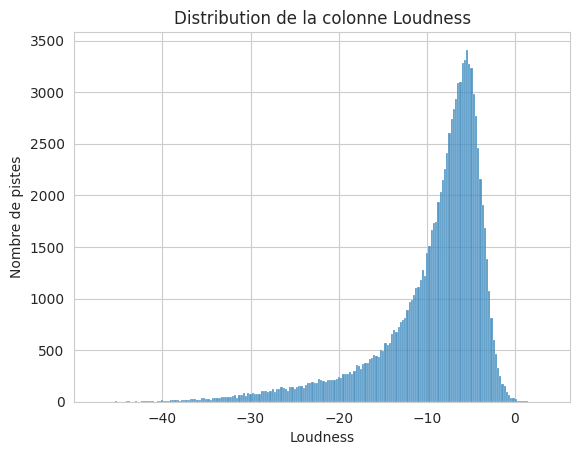

In [71]:
counts_loudness = df['loudness'].value_counts()
sns.histplot(data=df, x='loudness')
plt.title('Distribution de la colonne Loudness')
plt.xlabel('Loudness')
plt.ylabel('Nombre de pistes')
plt.show()

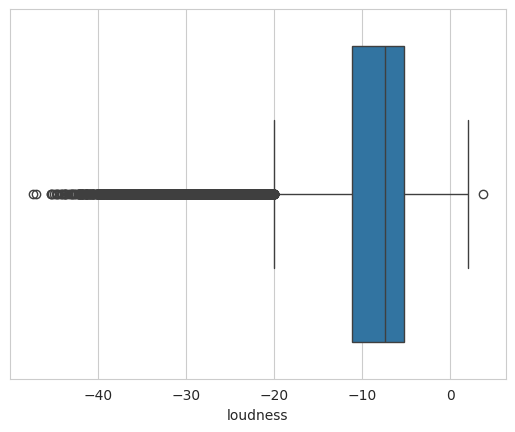

In [72]:
# Affichage d'une boite à moustache pour la variable "loudness"
# Mettre en évidence la présence d'outliers

sns.boxplot (data=df, x="loudness")
plt.show()

In [73]:
df = df[df['loudness'] <= 0]
df

,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
58300,maria callas,""" la traviata "" : amami alfredo (act ii) - dig...",0wtpkz93wATDkUExJVuXEl,31,0.993000,0.364,131933,0.275,0.028400,F,0.293,-11.832,Major,0.0430,86.096,4,0.0394
32571,yuki hayashi,"""1点""",7JkDONXIbcKUQ7QzlLBumL,23,0.025000,0.250,158000,0.762,0.516000,C#,0.094,-12.794,Minor,0.0468,89.093,3,0.0835
89661,rae sremmurd,"""42"" - from sr3mm",5lf91lPnGKtIqsgmG1z8Ip,53,0.002750,0.968,238020,0.563,0.000000,C#,0.108,-6.744,Major,0.1250,130.039,4,0.3240
142359,the gaslight anthem,"""45""",25Sd73fleKUVPNqITPZkn1,48,0.000696,0.315,202493,0.970,0.000000,G#,0.277,-4.709,Major,0.1020,178.068,4,0.4230
77209,barns courtney,"""99""",6YQUuoMnRIMaOmouYoMfQr,69,0.005980,0.552,199413,0.804,0.000000,G#,0.111,-4.299,Major,0.0303,95.980,4,0.7140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150871,got7,하드캐리 hard carry,7Cd4glTUgV0vr0DBncEg8S,63,0.014800,0.700,193579,0.873,0.000000,C#,0.343,-2.901,Major,0.0869,99.972,4,0.6120
219320,park hyo shin,해줄 수 없는 일 haejul su eomneun il,3Kk075LR7Bj2bUH1mB3TIZ,30,0.729000,0.332,260600,0.493,0.000000,C,0.165,-6.126,Major,0.0318,110.024,4,0.1550
149889,day6,행복했던 날들이었다 days gone by,3TE3SbiWrm69WyUl8BlZEV,64,0.002110,0.613,205149,0.874,0.000000,C,0.134,-3.712,Minor,0.0335,102.975,4,0.6510
220337,lee moon sae,휘파람,3G9dGrDJAPTDtJCGk8VF5i,27,0.513000,0.521,298760,0.423,0.000004,D,0.131,-6.770,Minor,0.0324,59.036,4,0.2740


In [74]:
print(f"Le dataset a désormais {len(df)} lignes.")

Le dataset a désormais 103292 lignes.


##### ***Speechiness***

In [75]:
df["speechiness"].describe().T

count    103292.000000
mean          0.100298
std           0.137958
min           0.022200
25%           0.036300
50%           0.048900
75%           0.096900
max           0.967000
Name: speechiness, dtype: float64

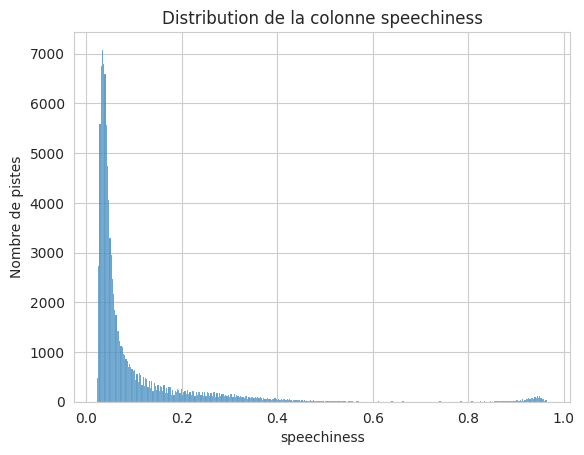

In [76]:
counts_key = df['speechiness'].value_counts()
sns.histplot(data=df, x="speechiness")
plt.title('Distribution de la colonne speechiness')
plt.xlabel('speechiness')
plt.ylabel('Nombre de pistes')
plt.show()

- On observe que la majorité des morceaux ont une "speechiness" faible (valeurs proches de 0).
- Les percentiles montrent que 90% des morceaux ont une valeur inférieure à 0.278, ce qui indique que les morceaux très "parlés" sont rares.
- La moyenne (mean) est de 0.120765, ce qui confirme que la plupart des morceaux contiennent peu de paroles selon ce critère.

In [77]:
df = df[df['speechiness']<=0.66]

In [78]:
print(f"Le dataset a désormais {len(df)} lignes.")

Le dataset a désormais 101554 lignes.


##### ***Valence***

In [79]:
df['valence'].describe()

count    101554.000000
mean          0.472079
std           0.265255
min           0.000000
25%           0.252000
50%           0.471000
75%           0.687000
max           1.000000
Name: valence, dtype: float64

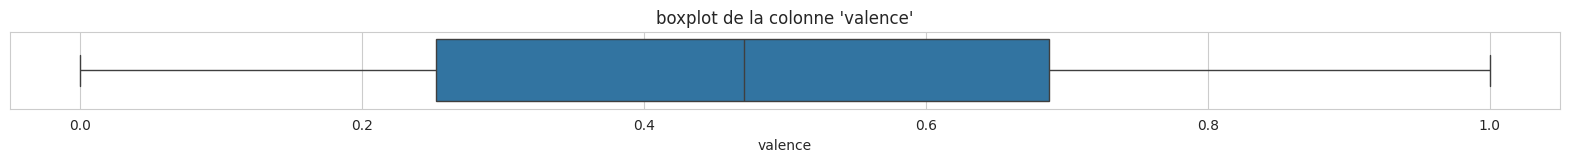

In [80]:
plt.figure(figsize=(20, 1))
sns.boxplot(x=df['valence'])
plt.title("boxplot de la colonne 'valence'")
plt.show()

Voir la corrélation avec le mode et peut être la clé.

**Appliquer le fichier clean_data.py dans le terminal**

Ce script permet de cleaner toute la df suite à l'analyse et au choix effectués.

In [81]:
"""

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from tqdm import tqdm
import numpy as np

# Chargement du CSV de base
df = pd.read_csv("SpotifyFeatures.csv")

# Remplissage de la valeur nulle
df = df.fillna('None')

# Retire la colonne genre
df= df.drop(columns=['genre'])

# Normalise les noms d'artiste pour éviter les doublons
df['artist_name'] = df['artist_name'].str.replace('’', "'",  regex=False)  # apostrophe typographique
df['artist_name'] = df['artist_name'].str.lower().str.strip()  # minuscule + suppression espaces 

# Normalise les noms des chansons 
df['track_name'] = df['track_name'].str.replace('’', "'",  regex=False)  # apostrophe typographique
df['track_name'] = df['track_name'].str.lower().str.strip()  # minuscule + suppression espaces  

# Crée une df des doublons de track_id
df_duplicates = df[df.duplicated(subset=['track_id'])]

audio_features = ['acousticness', 'danceability', 'duration_ms', 'energy', 
                  'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 
                  'speechiness', 'tempo', 'time_signature', 'valence']

# Identifier les track_id avec des valeurs incohérentes
problematic_tracks = []

for track_id, group in df_duplicates.groupby('track_id'):
    for col in audio_features:
        if group[col].nunique() > 1:
            problematic_tracks.append(track_id)
            break  

# Supprimer ces track_id du DataFrame
df_clean = df[~df['track_id'].isin(problematic_tracks)]

# Garder la ligne avec la popularité max pour chaque track_id
df = df_clean.loc[df_clean.groupby('track_id')['popularity'].idxmax()]

# Pour éviter les doublons, nous conservons la version la plus populaire pour chaque couple track_name / artist_name.
df= df.loc[df.groupby(['track_name', 'artist_name'])['popularity'].idxmax()]

# Extraire uniquement le numérateur de la signature [2, 3, 4, 5] pour en faire une colonne numérique propre.
# Étape 1 : Extraire la partie avant le '/' et la convertir en entier
df['time_signature_clean'] = df['time_signature'].str.extract(r'^(\d+)').astype('Int64')
df['time_signature'] = df['time_signature_clean']
df = df[df['time_signature'].isin([2, 3, 4, 5])]

# Pour chaque titre de chanson unique (track_name) sélectionne la ligne ayant la popularité maximale (popularity) dans le DataFrame df
df = df.loc[df.groupby('track_name')['popularity'].idxmax()]

# On décide de ne garder que les scores au dessus de 20/100 de popularité.
df = df[df['popularity'] >= 20] 

# duration_ms entre 1min et 6min
df = df[(df['duration_ms'] >= 60000) & (df['duration_ms'] <= 360000)]

# Garde les valeurs au dessus de 0.8 sur liveness
df = df[df['liveness'] < 0.8]

# Retire les lignes qui contiennent ces motifs: "- live", "(live)", "[live]"
df = df[~df['track_name'].str.contains(r"(?:-\s*live\b|\(live\)|\[live\])", case=False, na=False, regex=True)]

# Clean en gardant les valeurs entre les bornes
df = df[(df['tempo'] >= 23.82) & (df['tempo'] <= 208.20)]

# Clean des valeurs incohérentes de loudness au dessus de 0
df = df[df['loudness'] <= 0]

# Clean des possibles podcasts/conférences au dela de 0.66 sur speechiness
df_clean = df[df['speechiness']<=0.66]

df_clean.to_csv("clean.csv", index=False)

"""

'\n\nimport pandas as pd\nimport seaborn as sns\nimport matplotlib.pyplot as plt\nimport requests\nfrom tqdm import tqdm\nimport numpy as np\n\n# Chargement du CSV de base\ndf = pd.read_csv("SpotifyFeatures.csv")\n\n# Remplissage de la valeur nulle\ndf = df.fillna(\'None\')\n\n# Retire la colonne genre\ndf= df.drop(columns=[\'genre\'])\n\n# Normalise les noms d\'artiste pour éviter les doublons\ndf[\'artist_name\'] = df[\'artist_name\'].str.replace(\'’\', "\'",  regex=False)  # apostrophe typographique\ndf[\'artist_name\'] = df[\'artist_name\'].str.lower().str.strip()  # minuscule + suppression espaces \n\n# Normalise les noms des chansons \ndf[\'track_name\'] = df[\'track_name\'].str.replace(\'’\', "\'",  regex=False)  # apostrophe typographique\ndf[\'track_name\'] = df[\'track_name\'].str.lower().str.strip()  # minuscule + suppression espaces  \n\n# Crée une df des doublons de track_id\ndf_duplicates = df[df.duplicated(subset=[\'track_id\'])]\n\naudio_features = [\'acousticness\', \'

In [82]:
df= pd.read_csv("clean.csv")

In [83]:
colonnes_hors_corr = ['track_id','artist_name','track_name','key']
df_corr = df.drop(columns=colonnes_hors_corr)

La colonne time_signature est déjà transformée en valeurs numériques

In [84]:
df['time_signature'].unique()

array([4, 3, 1, 5])

In [85]:
df_corr = pd.get_dummies(df_corr, columns=['mode'])

In [86]:
corr_matrix = df_corr.corr(method='pearson')  
print(corr_matrix)

                      popularity  acousticness  danceability  duration_ms  \
popularity              1.000000     -0.182918      0.247609     0.043303   
acousticness           -0.182918      1.000000     -0.381886    -0.135636   
danceability            0.247609     -0.381886      1.000000     0.039327   
duration_ms             0.043303     -0.135636      0.039327     1.000000   
energy                  0.131232     -0.777855      0.355679     0.110704   
instrumentalness       -0.273337      0.405462     -0.421071    -0.098720   
liveness               -0.011302     -0.142594      0.004911    -0.007779   
loudness                0.235488     -0.695263      0.465174     0.138973   
speechiness             0.110008     -0.184439      0.269919    -0.056918   
tempo                   0.034656     -0.220697      0.018773     0.024555   
time_signature          0.078505     -0.213474      0.221756     0.043191   
valence                 0.048517     -0.346178      0.551203    -0.031458   

In [87]:
df_clean= pd.read_csv("clean.csv")

##### **Enrichissement des genres avec l'API Spotify**

- Créer un compte https://developer.spotify.com/documentation/web-api
- Créer une app:
    - Application URL : mettre http://localhost ou l'URL du projet
- Récupérer SPOTIFY_CLIENT_ID et SPOTIFY_CLIENT_SECRET
- Créer un fichier .env et ajouter:
    - SPOTIFY_CLIENT_ID=laclérécupérée
    - SPOTIFY_CLIENT_SECRET=lacléesecrèterécupérée

In [88]:
# Garde une ligne par artiste (première occurrence)
df_unique_artists = df.drop_duplicates(subset=['artist_name'])
df_unique_artists.to_csv("artists_unique.csv", index=False)

# Tri par popularité décroissante
# df_sorted = df_unique_artists.sort_values(by='popularity', ascending=False)

# Prend les 100 premiers (échantillon)
# df_top100 = df_sorted.head(100)

# Sauvegarde du top_100 pour test échantillon
# df_top100.to_csv("top_100.csv", index=False)

In [89]:
len(df_unique_artists)

12452

**Appliquer le script genre_par_artist.py :**

Ce script permet de récupérer les genres selon le nom des artistes

In [90]:
"""
import pandas as pd
import spotipy
import time
from spotipy.oauth2 import SpotifyClientCredentials
from dotenv import load_dotenv
import os
from tqdm import tqdm

# === 1. Authentification Spotify ===
load_dotenv()
client_id = os.getenv('SPOTIFY_CLIENT_ID')
client_secret = os.getenv('SPOTIFY_CLIENT_SECRET')
auth_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
sp = spotipy.Spotify(auth_manager=auth_manager)

# === 2. Charger les données et trier par popularité ===
df = pd.read_csv("artists_genre.csv")  # ou "top_100.csv" si on veut faire le test sur l'échantillon

# 1. Extraire la liste d'artistes
artists = df['artist_name']

artist_genres = {}

# 2. Pour chaque artiste, chercher son artist_id via recherche et récupérer les genres
for artist_name in tqdm(artists, desc="Récupération genres artistes"):
    try:
        results = sp.search(q=f'artist:{artist_name}', type='artist', limit=1)
        items = results['artists']['items']
        if items:
            artist_id = items[0]['id']
            genres = items[0]['genres']
            artist_genres[artist_name] = genres
        else:
            artist_genres[artist_name] = []
        time.sleep(0.1)
    except Exception as e:
        print(f"Erreur artiste {artist_name}: {e}")
        artist_genres[artist_name] = []

# 3. Ajouter une colonne genres dans le DataFrame à partir du mapping
df['genres'] = df['artist_name'].map(artist_genres)

df.to_csv("artists_with_genres.csv", index=False) # ou top100_with_genres.csv si on veut l'échantillon
print("Export terminé.")

"""


'\nimport pandas as pd\nimport spotipy\nimport time\nfrom spotipy.oauth2 import SpotifyClientCredentials\nfrom dotenv import load_dotenv\nimport os\nfrom tqdm import tqdm\n\n# === 1. Authentification Spotify ===\nload_dotenv()\nclient_id = os.getenv(\'SPOTIFY_CLIENT_ID\')\nclient_secret = os.getenv(\'SPOTIFY_CLIENT_SECRET\')\nauth_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)\nsp = spotipy.Spotify(auth_manager=auth_manager)\n\n# === 2. Charger les données et trier par popularité ===\ndf = pd.read_csv("artists_genre.csv")  # ou "top_100.csv" si on veut faire le test sur l\'échantillon\n\n# 1. Extraire la liste d\'artistes\nartists = df[\'artist_name\']\n\nartist_genres = {}\n\n# 2. Pour chaque artiste, chercher son artist_id via recherche et récupérer les genres\nfor artist_name in tqdm(artists, desc="Récupération genres artistes"):\n    try:\n        results = sp.search(q=f\'artist:{artist_name}\', type=\'artist\', limit=1)\n        items = result

In [91]:
#df_test = pd.read_csv("top100_with_genres.csv")
df_unique_artists_genres = pd.read_csv("artists_with_genres.csv")
cols_order = [
    'track_id',
    'track_name',
    'genres',
    'artist_name',
    'popularity',
    'duration_ms'
]

# Ajouter le reste des colonnes dans l'ordre original, sauf celles déjà listées
remaining_cols = [col for col in df.columns if col not in cols_order]

# Nouvelle liste complète des colonnes dans l'ordre voulu
new_order = cols_order + remaining_cols

# Réorganiser le DataFrame
df_ordered_artists= df_unique_artists_genres[new_order]

df_ordered_artists.head()

,track_id,track_name,genres,artist_name,popularity,duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,time_signature_clean
0,0wtpkz93wATDkUExJVuXEl,""" la traviata "" : amami alfredo (act ii) - dig...","['opera', 'classical']",maria callas,31,131933,0.993000,0.364,0.275,0.0284,F,0.293,-11.832,Major,0.0430,86.096,4,0.0394,4
1,7JkDONXIbcKUQ7QzlLBumL,"""1点""","['anime', 'soundtrack']",yuki hayashi,23,158000,0.025000,0.250,0.762,0.5160,C#,0.094,-12.794,Minor,0.0468,89.093,3,0.0835,3
2,5lf91lPnGKtIqsgmG1z8Ip,"""42"" - from sr3mm",[],rae sremmurd,53,238020,0.002750,0.968,0.563,0.0000,C#,0.108,-6.744,Major,0.1250,130.039,4,0.3240,4
3,25Sd73fleKUVPNqITPZkn1,"""45""",[],the gaslight anthem,48,202493,0.000696,0.315,0.970,0.0000,G#,0.277,-4.709,Major,0.1020,178.068,4,0.4230,4
4,6YQUuoMnRIMaOmouYoMfQr,"""99""",[],barns courtney,69,199413,0.005980,0.552,0.804,0.0000,G#,0.111,-4.299,Major,0.0303,95.980,4,0.7140,4


In [92]:
# Compte le nombre de colonnes implémentées de []
count_empty_genres = df_ordered_artists[df_ordered_artists['genres'] == '[]'].shape[0]
print(f"Nombre de lignes avec genres vides : {count_empty_genres}")

Nombre de lignes avec genres vides : 3841


In [93]:
# Tri par ordre alphabétique par artiste
df_ordered_artists = df_ordered_artists.sort_values(by='artist_name', ascending=True)

#### **Complétion avec l'API Last.fm**

- Créer un compte https://www.last.fm/join
- Créer une application https://www.last.fm/api/account/create:
    - Application URL : mettre http://localhost ou l'URL du projet
- Récupérer API Key 
- Placer la clé dans le fichier .env :
    - LASTFM_API_KEY=cléchiffréerécupérée



**Appliquer le script requete_lastfm.py :**

Ce script permet d'obtenir un dataframe des genres complétés sur les lignes encore vides.

In [94]:
"""

import pandas as pd
import requests
import os
from dotenv import load_dotenv
from tqdm import tqdm

# === 1. Chargement clé API Last.fm ===
load_dotenv()
LASTFM_API_KEY = os.getenv("LASTFM_API_KEY")

def get_lastfm_genres(artist_name):
    
    # Récupère les tags (genres) associés à un artiste via l'API Last.fm.
    
    url = "http://ws.audioscrobbler.com/2.0/"
    params = {
        "method": "artist.gettoptags",
        "artist": artist_name,
        "api_key": LASTFM_API_KEY,
        "format": "json"
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()

        if "toptags" in data and "tag" in data["toptags"]:
            tags = data["toptags"]["tag"]
            top_tags = [tag["name"] for tag in tags if int(tag.get("count", 0)) > 0]
            return top_tags[:3]  # max 3 genres
        else:
            return []
    except Exception as e:
        print(f"Erreur pour l'artiste '{artist_name}' : {e}")
        return []

# === 2. Charger les données ===
df = pd.read_csv("artists_with_genres.csv")

# === 3. Identifier les lignes où la colonne 'genres' contient exactement '[]'
# Attention : ici c’est une string, pas une vraie liste
mask_missing = df['genres'] == '[]'

# === 4. Compléter les genres vides avec Last.fm ===
for i, row in tqdm(df[mask_missing].iterrows(), total=mask_missing.sum(), desc="Complétion via Last.fm"):
    artist_name = row['artist_name']
    new_genres = get_lastfm_genres(artist_name)
    df.at[i, 'genres'] = str(new_genres)  # On stocke la liste comme string (comme le reste du fichier)

# === 5. Export du nouveau DataFrame ===
df.to_csv("artists_with_genres_completed.csv", index=False)
print("Fichier mis à jour : artists_with_genres_completed.csv")


"""

'\n\nimport pandas as pd\nimport requests\nimport os\nfrom dotenv import load_dotenv\nfrom tqdm import tqdm\n\n# === 1. Chargement clé API Last.fm ===\nload_dotenv()\nLASTFM_API_KEY = os.getenv("LASTFM_API_KEY")\n\ndef get_lastfm_genres(artist_name):\n    \n    # Récupère les tags (genres) associés à un artiste via l\'API Last.fm.\n    \n    url = "http://ws.audioscrobbler.com/2.0/"\n    params = {\n        "method": "artist.gettoptags",\n        "artist": artist_name,\n        "api_key": LASTFM_API_KEY,\n        "format": "json"\n    }\n\n    try:\n        response = requests.get(url, params=params, timeout=10)\n        response.raise_for_status()\n        data = response.json()\n\n        if "toptags" in data and "tag" in data["toptags"]:\n            tags = data["toptags"]["tag"]\n            top_tags = [tag["name"] for tag in tags if int(tag.get("count", 0)) > 0]\n            return top_tags[:3]  # max 3 genres\n        else:\n            return []\n    except Exception as e:\n    

In [95]:
df_artist_genres_complet= pd.read_csv('artists_with_genres_completed.csv')

In [96]:
len(df_artist_genres_complet)

12452

In [97]:
len(df_ordered_artists)

12452

Tous les noms d'artistes ont un genre musical après enrichissement.

In [98]:
df_enrichi_genres = df.merge(df_artist_genres_complet, on='artist_name', how='left')


In [99]:
df_enrichi_genres.columns

Index(['artist_name', 'track_name_x', 'track_id_x', 'popularity_x',
       'acousticness_x', 'danceability_x', 'duration_ms_x', 'energy_x',
       'instrumentalness_x', 'key_x', 'liveness_x', 'loudness_x', 'mode_x',
       'speechiness_x', 'tempo_x', 'time_signature_x', 'valence_x',
       'time_signature_clean_x', 'track_name_y', 'track_id_y', 'popularity_y',
       'acousticness_y', 'danceability_y', 'duration_ms_y', 'energy_y',
       'instrumentalness_y', 'key_y', 'liveness_y', 'loudness_y', 'mode_y',
       'speechiness_y', 'tempo_y', 'time_signature_y', 'valence_y',
       'time_signature_clean_y', 'genres'],
      dtype='object')

In [100]:
# Supprime les colonnes en double (avec suffixe '_y')
df_clean = df_enrichi_genres.drop(columns=[col for col in df_enrichi_genres.columns if col.endswith('_y') and col != 'genres'])

# Renomme les colonnes '_x' en noms normaux
df_clean.columns = [col.replace('_x', '') if col.endswith('_x') else col for col in df_clean.columns]


In [101]:
missing_genres = df_clean[df_clean['genres'].isna()]['artist_name'].unique()
print(len(missing_genres), "artistes sans genre")


0 artistes sans genre


In [102]:
len(df_clean)

101554

In [103]:
df_clean['date'] = df_clean['track_id'].str.extract(r'(\d{4})')

# COnvertit en float (car NaN ne peut pas être un int)
df_clean['date'] = pd.to_numeric(df_clean['date'], errors='coerce')

In [104]:
df_clean.loc[~df_clean['date'].between(1900, 2025), 'date'] = pd.NA

In [105]:
df_clean['date'].unique().sum()

np.float64(nan)

In [106]:
# Fonction de normalisation du titre
def normalize_title(title):
    title = title.lower()
    title = re.sub(r'\(.*?\)', '', title)              # Supprimer contenu entre parenthèses
    title = re.sub(r'remastered.*', '', title)         # Supprimer "remastered" et ce qui suit
    title = re.sub(r'\d{4}', '', title)                # Supprimer les années
    title = re.sub(r'[^a-z0-9\s]', '', title)          # Supprimer ponctuation
    title = re.sub(r'\s+', ' ', title).strip()         # Nettoyer les espaces
    return title

# Appliquer la fonction
df_clean['normalized_title'] = df_clean['track_name'].apply(normalize_title)

# Garder le plus populaire par artiste + titre normalisé
df_deduplicated = (
    df_clean.sort_values('popularity', ascending=False)
      .drop_duplicates(subset=['artist_name', 'normalized_title'], keep='first')
)

# Supprimer la colonne temporaire
df_deduplicated = df_deduplicated.drop(columns=['normalized_title'])

# Résultat
print(f"Nombre de chansons initial : {len(df_enrichi_genres)}")
print(f"Nombre après déduplication : {len(df_deduplicated)}")


Nombre de chansons initial : 101554
Nombre après déduplication : 99020


In [107]:
len(df_deduplicated['genres'].unique())

6731

In [108]:
df_deduplicated.to_csv('dédupliqué.csv')

***Voir distribution nouvelle colonne genre*** 

In [109]:

# Convertir en chaîne et chercher "fr" (insensible à la casse)
df_fr = df_deduplicated[df_deduplicated['genres'].astype(str).str.lower().str.contains("fr")]

print(df_fr)



              artist_name                                         track_name  \
32648               ninho                                       goutte d'eau   
44781     heuss l'enfoiré                                             khapta   
62247                 nsg                                            options   
8100                 ramz                                            barking   
76539               adele                                   someone like you   
...                   ...                                                ...   
70601           daft punk                                          round one   
91959           fela kuti                                             v.c. 7   
74520  christiane legrand  sifflez vite vite - de "pinocchio"/bande origi...   
61188           fela kuti                                            oloruka   
3351       emmanuel moire                                       aimer encore   

                     track_id  populari

In [110]:
df_fr.columns

Index(['artist_name', 'track_name', 'track_id', 'popularity', 'acousticness',
       'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key',
       'liveness', 'loudness', 'mode', 'speechiness', 'tempo',
       'time_signature', 'valence', 'time_signature_clean', 'genres', 'date'],
      dtype='object')

TROUVER METHODE POUR ENRICHIR DE LIGNES DE VARIETE FRANCAISE avec API spotify, 
voir doc  pour nombre de lignes à charger

- Récupère les tracks avec leurs métadonnées basiques (track_id, track_name, artist_name, popularity, duration_ms)

- Pour chaque batch (max 100 tracks), appelle audio_features() pour récupérer les features audio:
Ces features audio sont disponibles via un endpoint différent, Audio Features API.

#### **Enrichissement nom d'album**

In [111]:
pd.read_csv('df_classé_par_genre.csv')

,Unnamed: 0,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,...,speechiness,tempo,time_signature,valence,time_signature_clean,genres,date,genre_group,artist_normalized,genre_simplifié
0,38149,paula cole,i don't want to wait,5MDQNJ7SZTytJwCbWKqJDL,62,0.2980,0.410,320027,0.468,0.000012,...,0.0553,177.508,4,0.475,4,"['female vocalists', 'singer-songwriter', 'pop']",NaN,Autres,paula cole,jazz/blues
1,38159,timmies,i dont wanna know her,4rKMHsVEAGTsA7hpKXnWrM,62,0.6020,0.835,122205,0.288,0.004610,...,0.3410,109.934,3,0.359,3,"['Lo-Fi', 'beats', 'chill']",NaN,Autres,timmies,pop
2,38165,death cab for cutie,i dreamt we spoke again,6TRQPx5Z0YZ0pCQX7JbtlS,62,0.2760,0.708,184827,0.706,0.006310,...,0.0385,119.027,4,0.450,4,"['indie', 'indie rock', 'alternative']",NaN,Autres,death cab for cutie,électro/dance
3,10079,glass animals,black mambo,63OC8cNa4ZnFB3bbvbWCOc,62,0.2940,0.675,248920,0.409,0.000596,...,0.0423,79.954,4,0.308,4,"['electronic', 'seen live', 'trip-hop']",NaN,Autres,glass animals,pop
4,82032,dua lipa,tears dry on their own - acoustic,6ftZrt4wcgSHokKl7ice5y,62,0.0513,0.704,196632,0.588,0.000000,...,0.0467,125.965,4,0.708,4,['pop'],NaN,Autres,dua lipa,électro/dance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,13273,pedro capó,calma - remix,5iwz1NiezX7WWjnCgY5TH4,97,0.3230,0.826,238200,0.773,0.000000,...,0.0524,126.899,4,0.761,4,"['latin pop', 'latin']",NaN,Autres,pedro capo,électro/dance
9996,16953,daddy yankee,con calma,5w9c2J52mkdntKOmRLeM2m,98,0.1100,0.737,193227,0.860,0.000002,...,0.0593,93.989,4,0.656,4,"['reggaeton', 'latin']",NaN,Autres,daddy yankee,rock/indie
9997,11761,ariana grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,99,0.0421,0.726,190440,0.554,0.000000,...,0.0917,169.999,4,0.335,4,['pop'],NaN,Autres,ariana grande,électro/dance
9998,97865,post malone,wow.,6MWtB6iiXyIwun0YzU6DFP,99,0.1630,0.833,149520,0.539,0.000002,...,0.1780,99.947,4,0.385,4,"['Hip-Hop', 'rap', 'trap']",NaN,Autres,post malone,pop


In [112]:
link = 'https://developer.spotify.com/'
r = requests.get(link).json()

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

#### **Enrichissement date de sortie**

In [ ]:
'''
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import pandas as pd
import time
from tqdm import tqdm

client_id = "TON_CLIENT_ID"
client_secret = "TON_CLIENT_SECRET"

auth_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
sp = spotipy.Spotify(auth_manager=auth_manager)

df = pd.read_csv("dédupliqué.csv")

def extract_track_id(uri):
    if isinstance(uri, str) and uri.startswith("spotify:track:"):
        return uri.split(":")[-1]
    return None

def get_release_year(track_id):
    if not track_id:
        return None
    try:
        track = sp.track(track_id)
        release_date = track['album']['release_date']
        year = release_date.split("-")[0]
        return int(year)
    except Exception as e:
        print(f"Erreur pour track_id {track_id}: {e}")
        return None

def safe_get_release_year(track_id):
    time.sleep(0.1)
    return get_release_year(track_id)

df['spotify_id'] = df['track_id'].apply(extract_track_id)

# Préparation tqdm avec suivi du temps
start_time = time.time()

results = []
for track_id in tqdm(df['spotify_id'], desc="Récupération années"):
    res = safe_get_release_year(track_id)
    results.append(res)
    elapsed = time.time() - start_time
df['release_year'] = results
df.to_csv("dédupliqué_avec_année.csv", index=False)
print("Terminé.")
'''

Pour le test on décide de garder 10000 lignes 
Pour le MVP(Minimu valable product) on en gardera entre 20000 et 500000

In [ ]:
df_test = df_deduplicated.sort_values('popularity').tail(10000)
df_test.to_csv('df_test.csv')

#### **Enrichissement paroles**

va permettre de distinguer la variété française ?

In [ ]:
df_test.columns

NameError: name 'df_test' is not defined

#### **Enrichissement pochettes d'album**

#### **Tag d'humeur**

#### **Tag d'activité**

In [160]:
df_fr_kaggle = pd.read_csv("dataset_fr.csv")

In [161]:
df_fr_kaggle = df_fr_kaggle.rename(columns={"artists": "artist_name"})


In [162]:
df_fr_kaggle = df_fr_kaggle.drop(df_fr_kaggle.columns[:2], axis=1)
df_fr_kaggle = df_fr_kaggle.drop('track_genre', axis=1)


In [163]:
colonnes_ordre = [
    'artist_name', 'track_name', 'track_id', 'popularity',
    'acousticness', 'danceability', 'duration_ms', 'energy',
    'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
    'speechiness', 'tempo', 'time_signature', 'valence',
]

# Réorganisation des colonnes
df_fr_kaggle = df_fr_kaggle[colonnes_ordre]


In [164]:
df_fr_kaggle

,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Christophe,Aline,7Jqh8o6yV7EeFokJX5gQsa,24,0.40600,0.274,170840,0.659,0.000019,0,0.3460,-5.557,1,0.0334,177.732,3,0.532
1,Indila,Love Story,6nGeLlakfzlBcFdZXteDq7,75,0.81500,0.375,316280,0.255,0.000000,10,0.0845,-12.279,0,0.0376,95.978,3,0.331
2,Indila,Tourner Dans Le Vide,1MqzIgGsHP4cNjPboevsfq,78,0.10300,0.594,246093,0.698,0.000000,6,0.1730,-8.645,0,0.0428,119.991,4,0.376
3,Indila,Dernière danse,65uoaqX5qcjXZRheAj1qQT,76,0.18400,0.669,213493,0.449,0.000000,0,0.0729,-7.658,0,0.0489,114.926,4,0.327
4,Indila,Ainsi bas la vida,4lsOsGMzO1yCjGVucoWOZ1,72,0.04860,0.776,214760,0.641,0.000006,8,0.0977,-6.925,1,0.0981,128.050,4,0.437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,Indochine,3e sexe - Mix 2020,3dmWPcPgCCWWWK69GAp4RJ,23,0.01990,0.662,243546,0.901,0.001560,5,0.0414,-5.094,0,0.0329,148.726,4,0.985
123,Indochine,Kissing My Song,1B1BylhpWOuG6NLKvw7fav,22,0.00115,0.420,244000,0.908,0.095300,2,0.1380,-4.548,1,0.0299,80.439,4,0.868
124,Indochine,L'aventurier,2UC5XnHA1Wn9FjQmbjNca9,64,0.25400,0.556,231960,0.909,0.000580,4,0.0971,-9.982,1,0.0444,167.101,4,0.633
125,Indochine,Junior Song,0bN42EvqOVQSVDLpjnrYPU,22,0.39300,0.627,189946,0.693,0.000358,8,0.0872,-8.539,1,0.0233,93.993,4,0.652


In [166]:
df_fr_original= pd.read_csv("dataset_fr_origin.csv")

In [167]:
df_fr_original= df_fr_original.drop(df_fr_original.columns[:2], axis=1)

In [168]:
colonnes_ordre = [
    'artist_name', 'track_name', 'track_id', 'popularity',
    'acousticness', 'danceability', 'duration_ms', 'energy',
    'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
    'speechiness', 'tempo', 'time_signature', 'valence',
]

# Réorganisation des colonnes
df_fr_original = df_fr_original[colonnes_ordre]

In [169]:
df_fr_original

,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Daniel Lavoie,Baby Boom,5AfBZUNgaHuET8mOHqDXrJ,12,0.930000,0.302,119533,0.385,0.091700,A,0.368,-23.864,Major,0.1200,116.214,4/4,0.297
1,Manu Chao,Me Gustas Tu,6b37xrsNCWYIUphFBazqD6,68,0.663000,0.657,239987,0.741,0.494000,B,0.222,-6.822,Minor,0.0825,175.949,4/4,0.908
2,Manu Chao,Bongo Bong,00SmB7n85SKROGjybsyq5i,64,0.944000,0.755,158427,0.545,0.000118,A,0.144,-10.027,Minor,0.0646,149.807,4/4,0.964
3,Manu Chao,Clandestino,51R2M1JgyFfRS3e6v5wCt3,60,0.469000,0.680,149173,0.594,0.000000,F#,0.431,-6.417,Minor,0.0688,85.040,4/4,0.774
4,Manu Chao,Desaparecido,5Hc7O2dX51NI4YcHPuoOpw,59,0.669000,0.591,227160,0.627,0.000000,A,0.127,-6.903,Minor,0.0935,191.944,4/4,0.741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,Manu Chao,Por Donde Saldra El Sol?,5zaMrkrdSQ4zW9Vp9FtwFJ,39,0.237000,0.433,161467,0.953,0.000000,C,0.566,-5.118,Major,0.1960,111.389,4/4,0.340
393,Manu Chao,Peligro,62OEOeExPAzV1pHNoBhrWU,39,0.000866,0.288,249867,0.948,0.001760,G,0.489,-5.139,Major,0.1740,179.344,4/4,0.522
394,Manu Chao,EZLN...Para tod@s todo...,0OqGHZW05syPxtnlxcTeq5,37,0.341000,0.581,101107,0.833,0.065300,A#,0.951,-10.889,Minor,0.0832,76.012,4/4,0.745
395,Manu Chao,La Despedida / Mentira,65tCSOR5Fuk4lA7XHkxZKJ,38,0.376000,0.391,264573,0.867,0.000147,A,0.769,-6.633,Minor,0.0993,83.329,4/4,0.438


In [177]:
df_total = pd.concat([df_fr_kaggle, df_fr_original], ignore_index=True)
df_total['genre'] = 'variété française'
df_total = df_total.loc[df_total.groupby('track_id')['popularity'].idxmax()]
df_total.to_csv('df_fr.csv', index=False)


In [ ]:
df = pd.read_csv('df_fr.csv')

,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,genre
0,Manu Chao,Bongo Bong,00SmB7n85SKROGjybsyq5i,68,0.944000,0.755,158427,0.545,0.000118,A,0.1440,-10.027,Minor,0.0646,149.807,4/4,0.964,variété française
1,Mylène Farmer,Désenchantée,01ugCDMaqFgnjKtXl0O2CE,34,0.001900,0.614,322760,0.655,0.126000,10,0.0844,-11.744,0,0.0297,125.905,4,0.342,variété française
2,Daft Punk,Superheroes / Human After All / Rock'n Roll,029O4HWI1pVXLfFdfQd1Jb,45,0.000045,0.487,341107,0.723,0.383000,G,0.8190,-11.148,Major,0.1430,138.007,4/4,0.391,variété française
3,Daniel Lavoie,À boire ! - Live,039VlTNI7azq5YaNTehzdp,8,0.840000,0.322,93627,0.188,0.001750,A#,0.1150,-16.733,Major,0.0395,65.949,4/4,0.276,variété française
4,Georges Brassens,Chanson pour l'auvergnat,03i4HQaxKuef4sNUTB3txK,32,0.895000,0.576,184267,0.151,0.000000,B,0.1180,-13.329,Minor,0.2620,200.772,3/4,0.744,variété française
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,Indochine,Alice & June - Mix 2020,7taoYAfDTtuI5dxSBeijUO,31,0.002530,0.456,208986,0.888,0.021400,2,0.3220,-6.360,0,0.0756,136.114,4,0.315,variété française
503,Daft Punk,Face To Face,7v9Q0dAb9t7h8gJOkcJHay,60,0.001350,0.874,240173,0.437,0.029600,C#,0.0293,-10.234,Minor,0.0706,117.790,4/4,0.963,variété française
504,Indochine,Kao-Bang,7vF96I0HMD5K9Kegajopxm,25,0.064400,0.715,297093,0.879,0.001070,5,0.1510,-10.014,0,0.0632,125.977,4,0.777,variété française
505,Francis Lalanne,On se retrouvera - Live,7wrnWnYp1LIaQS5h11lz2F,6,0.373000,0.352,351693,0.613,0.000205,C,0.9610,-6.533,Major,0.0478,126.018,4/4,0.165,variété française
